In [1]:
import xarray as xr
import numpy as np
from dask.diagnostics import ProgressBar

In [ ]:
print(f"NoData value: {CLC.rio.nodata}")

# Create a lookup table
max_val = 48
lut = np.full(max_val + 1, 255, dtype=np.uint8)

for v in [31, 34, 37, 38, 39, 40, 41, 42, 43, 44]:
    lut[v] = 0
for v in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 20, 30, 32, 33, 35]:
    lut[v] = 1
for v in [15, 16, 17, 18, 19, 21, 22, 36]:
    lut[v] = 2
for v in [23, 24, 25, 26, 27, 28, 29]:
    lut[v] = 3

def apply_lut(data, lut, nodata_in):
    result = np.full(data.shape, 255, dtype=np.uint8)
    valid_mask = (data >= 0) & (data <= len(lut) - 1)
    if nodata_in is not None:
        valid_mask = valid_mask & (data != nodata_in)
    result[valid_mask] = lut[data[valid_mask].astype(np.intp)]
    return result

fire_susceptibility = xr.apply_ufunc(
    apply_lut,
    CLC,
    kwargs={"lut": lut, "nodata_in": CLC.rio.nodata},
    dask="parallelized",
    output_dtypes=[np.uint8],
)

fire_susceptibility.rio.write_crs(CLC.rio.crs, inplace=True)
fire_susceptibility.rio.write_nodata(255, inplace=True)

# Compute with single progress bar, then write
print("Processing...")
with ProgressBar():
    result = fire_susceptibility.compute()

print("Writing to disk...")
result.rio.to_raster(
    r"C:\Data\CLC\DATA\fire_susceptibility.tif",
    tiled=True,
    compress="LZW",
    dtype=np.uint8,
)

print("Done!")

In [2]:
fire_susceptibility = xr.open_dataset(
    r"C:\Data\CLC\DATA\fire_susceptibility.tif",
    engine="rasterio",
)

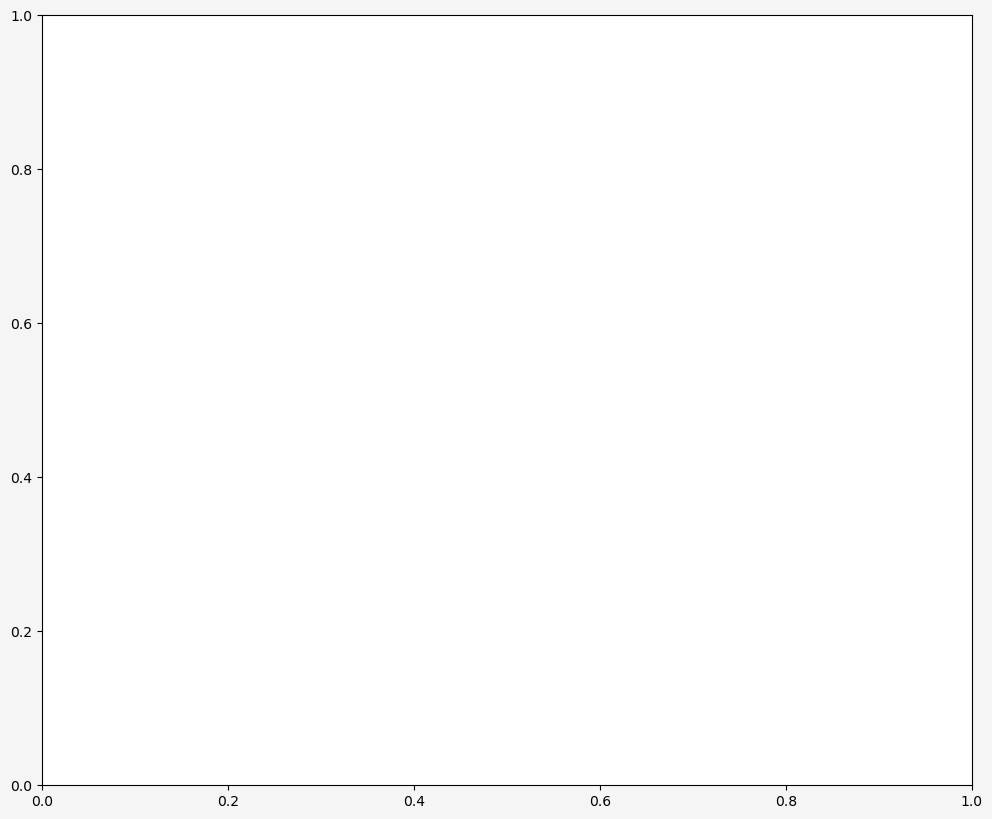

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# Define discrete colormap for 3 classes
colors = ['#84a98c', '#f4a261', '#d00000']  # green, orange, red
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]  # boundaries between classes
norm = BoundaryNorm(bounds, cmap.N)

# Plot the raster (squeeze to remove band dimension)
data = fire_susceptibility['band_data'].squeeze()

# # Use imshow with extent from coordinates
# data.plot.imshow(
#     ax=ax,
#     cmap=cmap,
#     norm=norm,
#     add_colorbar=False,
#     add_labels=False,
# )

# Downsample by factor of 10 for faster plotting
data_small = data.coarsen(x=10, y=10, boundary='trim').max()  # use max to preserve high susceptibility



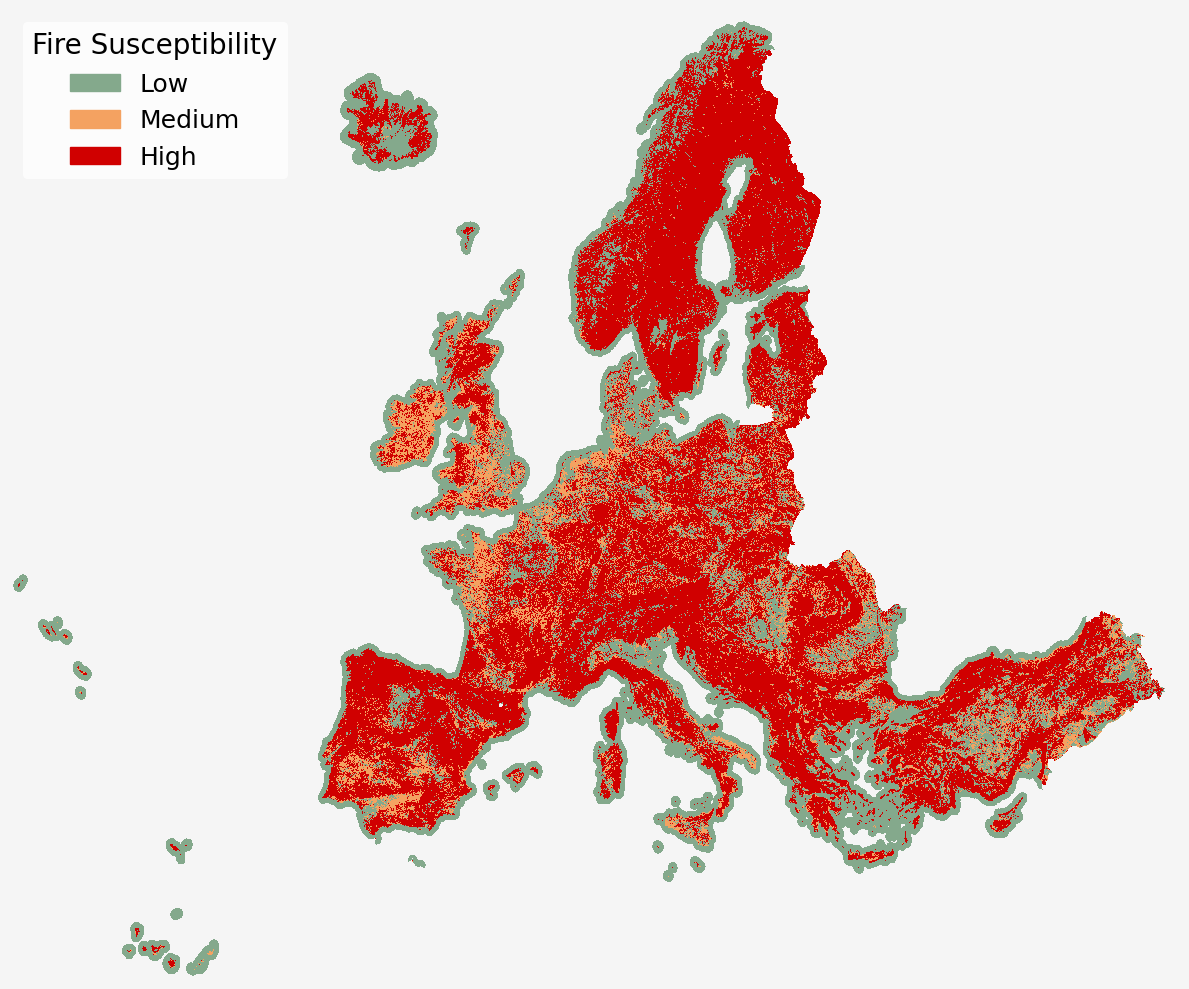

In [7]:
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#f5f5f5')

data_small.plot.imshow(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
)


# Create legend patches
legend_patches = [
    mpatches.Patch(color='#84a98c', label='Low'),
    mpatches.Patch(color='#f4a261', label='Medium'),
    mpatches.Patch(color='#d00000', label='High'),
]

ax.legend(
    handles=legend_patches,
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='none',
    fontsize=18,
    title='Fire Susceptibility',
    title_fontsize=20,
)

# Remove axes
ax.set_axis_off()

plt.tight_layout()
plt.savefig('fire_susceptibility_map.png', dpi=300, bbox_inches='tight') #, facecolor='#f5f5f5')
plt.show()